<a href="https://colab.research.google.com/github/thennakoondinuradilshan-glitch/AI-Projects/blob/main/Amazon_Sales_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Amazon India — Sales Data Analysis
## Mini Project — Excel to Python Bootcamp

**Scenario:** You are a Junior Data Analyst at Amazon India, analyzing sales transaction data from the operations and sales team to help management plan strategy for the upcoming quarter.

### ⚠️ Important Data Note
The provided `Amazon.csv` dataset does not contain explicit **Profit** or **Sub-Category** columns. The following assumptions were used in this analysis:

- **Profit:** Assumed as a 22% profit margin of `TotalAmount` → `Profit = TotalAmount × 0.22`. (This is an assumed value for analysis purposes only, not an actual profit figure.)
- **Sub-Category:** The dataset's **Brand** column is used as a substitute for Sub-Category.

It is recommended to confirm these assumptions with your instructor.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## Dataset Loading
**Q1.** Load the Amazon_Sales dataset (Amazon.csv) into a Pandas DataFrame and display the first 5 records.

In [5]:
df = pd.read_csv('Amazon_Sales_Clean.csv', parse_dates=['OrderDate'])
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'Amazon_Sales_Clean.csv'

## Dataset Overview
**Q2.** Show the number of rows/columns, column names, data types, and summary statistics for numeric columns.

In [6]:
print('Rows, Columns:', df.shape)


NameError: name 'df' is not defined

In [ ]:
print('Column Names:')
print(df.columns.tolist())


Column Names:
['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID', 'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus', 'City', 'State', 'Country', 'SellerID', 'Profit', 'OrderMonth', 'OrderYear', 'MonthName']


In [ ]:
df.dtypes


OrderID                     str
OrderDate        datetime64[us]
CustomerID                  str
CustomerName                str
ProductID                   str
ProductName                 str
Category                    str
Brand                       str
Quantity                  int64
UnitPrice               float64
Discount                float64
Tax                     float64
ShippingCost            float64
TotalAmount             float64
PaymentMethod               str
OrderStatus                 str
City                        str
State                       str
Country                     str
SellerID                    str
Profit                  float64
OrderMonth                  str
OrderYear                 int64
MonthName                   str
dtype: object

In [ ]:
df.describe()


,OrderDate,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,Profit,OrderYear
count,100000,"100,000.00","100,000.00","100,000.00","100,000.00","100,000.00","100,000.00","100,000.00","100,000.00"
mean,2022-06-30 23:55:49.439999,3.00,302.91,0.07,68.47,7.41,918.26,202.02,"2,022.00"
min,2020-01-01 00:00:00,1.00,5.00,0.00,0.00,0.00,4.27,0.94,"2,020.00"
25%,2021-04-01 00:00:00,2.00,154.19,0.00,15.92,3.68,340.89,75.00,"2,021.00"
50%,2022-07-01 00:00:00,3.00,303.07,0.05,45.25,7.30,714.32,157.15,"2,022.00"
75%,2023-09-29 00:00:00,4.00,451.50,0.10,96.06,11.15,"1,349.76",296.95,"2,023.00"
max,2024-12-29 00:00:00,5.00,599.99,0.30,538.46,15.00,"3,534.98",777.70,"2,024.00"
std,NaN,1.41,171.84,0.08,74.13,4.32,724.51,159.39,1.41


## KPI Analysis
**Q3.** Calculate the following KPIs: Total Sales, Total Profit, Total Orders, Average Sales, Average Profit, Maximum Sales, Minimum Sales.

In [ ]:
total_sales = df['TotalAmount'].sum()
total_profit = df['Profit'].sum()
total_orders = df['OrderID'].nunique()
avg_sales = df['TotalAmount'].mean()
avg_profit = df['Profit'].mean()
max_sales = df['TotalAmount'].max()
min_sales = df['TotalAmount'].min()

print(f'Total Sales      : {total_sales:,.2f}')
print(f'Total Profit     : {total_profit:,.2f}')
print(f'Total Orders     : {total_orders:,}')
print(f'Average Sales    : {avg_sales:,.2f}')
print(f'Average Profit   : {avg_profit:,.2f}')
print(f'Maximum Sales    : {max_sales:,.2f}')
print(f'Minimum Sales    : {min_sales:,.2f}')


Total Sales      : 91,825,647.92
Total Profit     : 20,201,643.92
Total Orders     : 100,000
Average Sales    : 918.26
Average Profit   : 202.02
Maximum Sales    : 3,534.98
Minimum Sales    : 4.27


## Sales Analysis
**Q4.** Find total sales by **State**, sorted in descending order.

In [ ]:
sales_by_state = df.groupby('State')['TotalAmount'].sum().sort_values(ascending=False)
sales_by_state


State
TX   22,862,540.54
CA   18,231,196.79
NC    4,747,701.73
WA    4,660,962.17
PA    4,650,673.88
CO    4,638,498.97
IL    4,632,847.44
OH    4,615,442.32
IN    4,609,048.43
FL    4,597,177.27
NY    4,554,358.08
DC    4,520,876.11
AZ    4,504,324.19
Name: TotalAmount, dtype: float64

**Q5.** Find total sales by **Category**.

In [ ]:
sales_by_category = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)
sales_by_category


Category
Electronics         15,584,217.18
Sports & Outdoors   15,345,571.88
Books               15,261,837.01
Clothing            15,253,397.50
Toys & Games        15,216,684.99
Home & Kitchen      15,163,939.36
Name: TotalAmount, dtype: float64

**Q7.** Find total sales by **Sub-Category** (represented by the Brand column).

In [ ]:
sales_by_subcategory = df.groupby('Brand')['TotalAmount'].sum().sort_values(ascending=False)
sales_by_subcategory


Brand
CoreTech     9,343,720.59
KiddoFun     9,324,749.55
ReadMore     9,278,406.63
UrbanStyle   9,249,027.45
Zenith       9,239,960.39
Apex         9,147,604.72
NexPro       9,078,824.97
FitLife      9,061,444.68
BrightLux    9,056,816.11
HomeEase     9,045,092.83
Name: TotalAmount, dtype: float64

## Customer & Product Analysis
**Q9.** Show the **top 5 customers** by total sales.

In [ ]:
top5_customers = df.groupby('CustomerName')['TotalAmount'].sum().sort_values(ascending=False).head(5)
top5_customers


CustomerName
Pooja Kapoor   547,832.64
Vihaan Singh   526,675.89
Pooja Singh    516,451.45
Kabir Joshi    515,361.68
Aditya Gupta   515,005.09
Name: TotalAmount, dtype: float64

**Q10.** Find the total quantity sold for each product.

In [ ]:
qty_by_product = df.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False)
qty_by_product.head(10)


ProductName
LED Desk Lamp          6344
Water Bottle           6275
Memory Card 128GB      6240
Router                 6202
Board Game             6200
Microphone             6196
Gaming Mouse           6170
Electric Kettle        6165
Mechanical Keyboard    6161
Vacuum Cleaner         6139
Name: Quantity, dtype: int64

## Payment Analysis
**Q11.** Find the number of orders placed using each **Payment Mode**.

In [ ]:
orders_by_payment = df.groupby('PaymentMethod')['OrderID'].count().sort_values(ascending=False)
orders_by_payment


PaymentMethod
Credit Card         35038
Debit Card          20024
UPI                 15066
Amazon Pay          15017
Net Banking          9927
Cash on Delivery     4928
Name: OrderID, dtype: int64

## Time-based Analysis
**Q12.** Using the **Order Date** column, calculate the monthly sales trend.

In [ ]:
df['OrderMonth'] = df['OrderDate'].dt.to_period('M')
monthly_sales = df.groupby('OrderMonth')['TotalAmount'].sum()
monthly_sales.tail(12)


OrderMonth
2024-01   1,493,946.70
2024-02   1,412,146.91
2024-03   1,548,280.27
2024-04   1,511,151.55
2024-05   1,642,609.94
2024-06   1,541,772.48
2024-07   1,469,460.10
2024-08   1,577,272.85
2024-09   1,468,209.92
2024-10   1,520,332.67
2024-11   1,529,791.33
2024-12   1,451,073.77
Freq: M, Name: TotalAmount, dtype: float64

## Multi-level Analysis
**Q13.** For each **State**, find the sales by **Category**. (Use `groupby()` with multiple columns.)

In [ ]:
state_category_sales = df.groupby(['State', 'Category'])['TotalAmount'].sum().unstack()
state_category_sales


Category,Books,Clothing,Electronics,Home & Kitchen,Sports & Outdoors,Toys & Games
State,,,,,,
AZ,"793,211.33","691,249.82","747,955.37","737,616.34","694,318.06","839,973.27"
CA,"3,017,185.92","3,023,142.96","3,097,298.03","2,948,476.21","3,066,014.83","3,079,078.84"
CO,"723,091.57","770,834.13","834,412.38","755,753.00","763,128.07","791,279.82"
DC,"777,425.52","720,698.56","770,229.92","754,162.78","754,460.34","743,898.99"
FL,"787,172.34","765,418.40","808,848.82","744,274.37","763,046.66","728,416.68"
IL,"743,537.33","773,800.22","730,209.49","787,486.47","770,076.57","827,737.36"
IN,"770,096.16","789,703.50","783,581.43","814,176.12","747,971.74","703,519.48"
NC,"754,267.67","846,756.20","793,593.35","798,677.84","797,400.80","757,005.87"
NY,"774,918.52","695,809.61","779,739.43","760,755.79","789,657.41","753,477.32"


## Visualization
**Q15.** Create a **Bar Chart** showing sales by State.

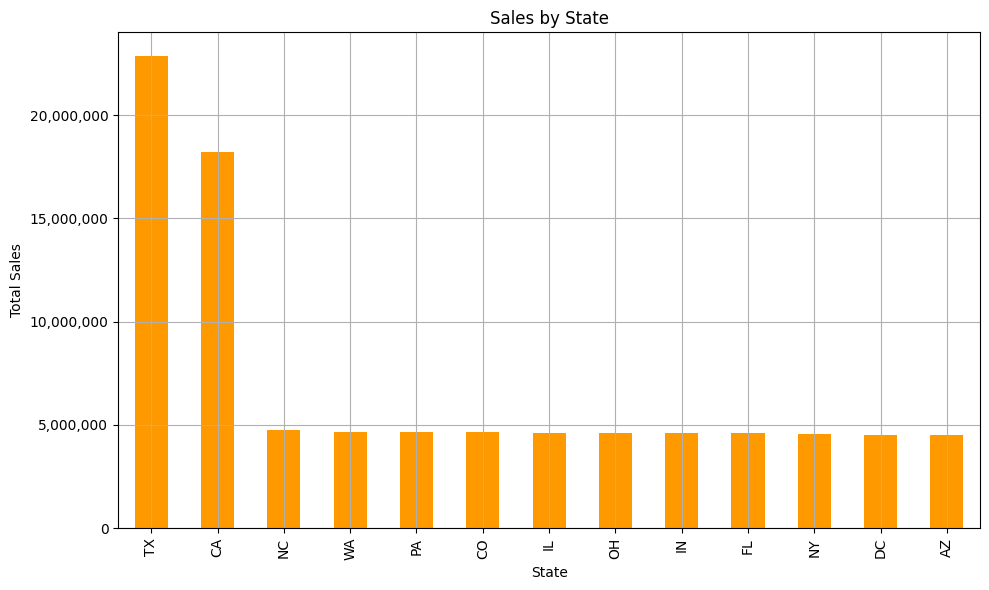

In [ ]:
fig, ax = plt.subplots()
sales_by_state.plot(kind='bar', color='#FF9900', ax=ax)
ax.set_title('Sales by State')
ax.set_xlabel('State')
ax.set_ylabel('Total Sales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('chart_sales_by_state_en.png', dpi=150)
plt.show()


**Q16.** Create a **Pie Chart** showing sales by Category.

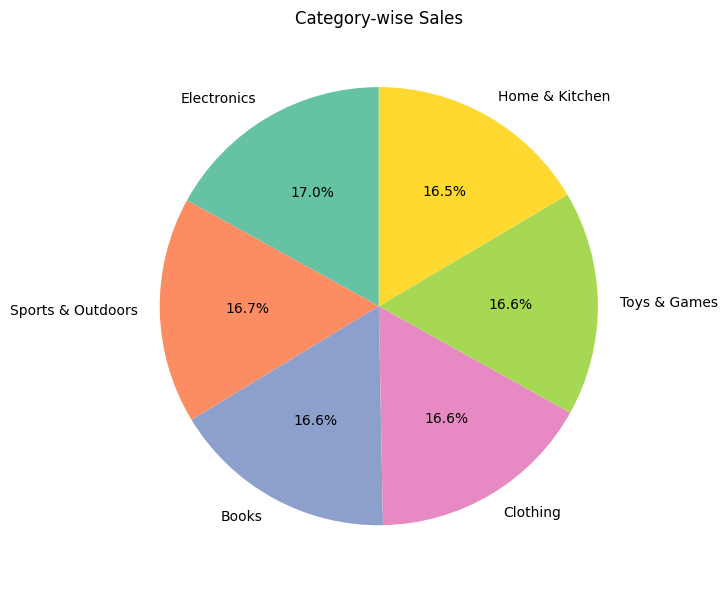

In [ ]:
fig, ax = plt.subplots()
ax.pie(sales_by_category, labels=sales_by_category.index, autopct='%1.1f%%',
       colors=plt.cm.Set2.colors, startangle=90)
ax.set_title('Category-wise Sales')
plt.tight_layout()
plt.savefig('chart_sales_by_category_en.png', dpi=150)
plt.show()


**Q17.** Create a **Line Chart** showing the monthly sales trend.

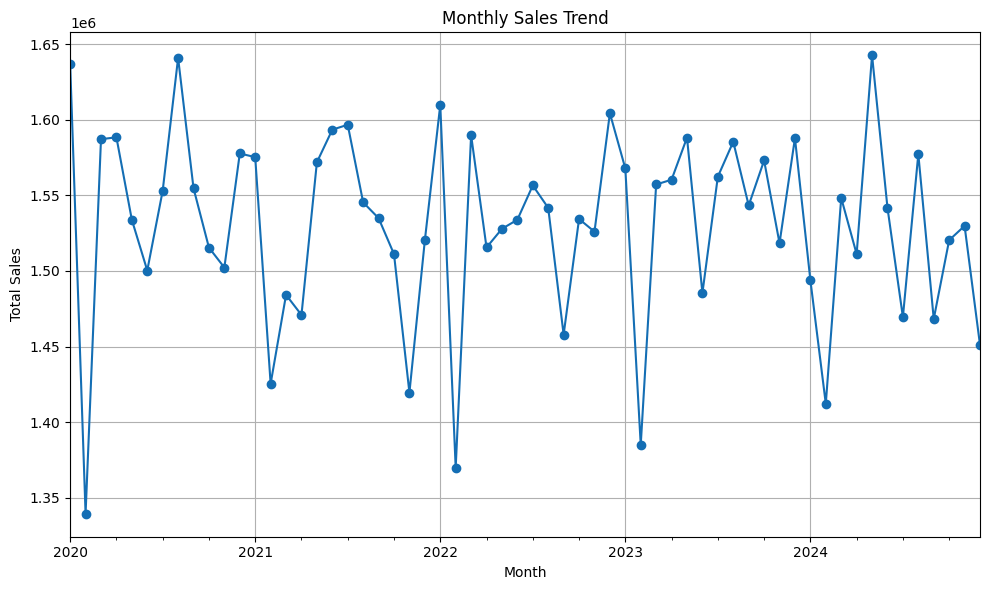

In [ ]:
fig, ax = plt.subplots()
monthly_sales.plot(kind='line', marker='o', color='#146EB4', ax=ax)
ax.set_title('Monthly Sales Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales')
plt.tight_layout()
plt.savefig('chart_monthly_trend_en.png', dpi=150)
plt.show()


**Q18.** Create a **Horizontal Bar Chart** showing the top 10 products by sales.

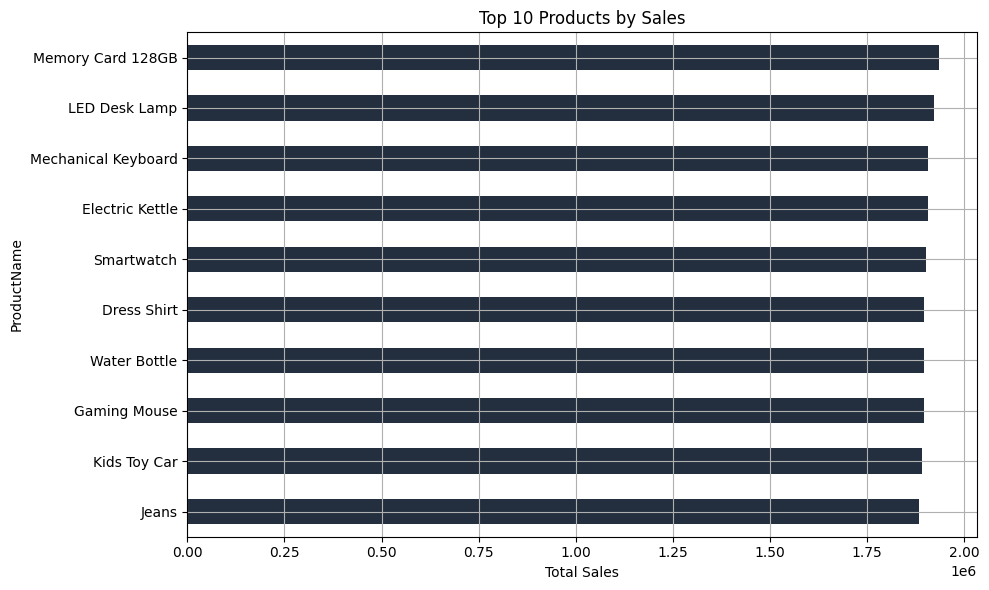

In [ ]:
top10_products = df.groupby('ProductName')['TotalAmount'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
top10_products.sort_values().plot(kind='barh', color='#232F3E', ax=ax)
ax.set_title('Top 10 Products by Sales')
ax.set_xlabel('Total Sales')
plt.tight_layout()
plt.savefig('chart_top10_products_en.png', dpi=150)
plt.show()


## Business Questions — Answers for Management

The answers below are based on the results computed above.

In [ ]:
avg_order_value = df.groupby('OrderID')['TotalAmount'].sum().mean()
print(f'Total Sales          : {total_sales:,.2f}')
print(f'Total Profit         : {total_profit:,.2f}')
print(f'Average Order Value  : {avg_order_value:,.2f}')


Total Sales          : 91,825,647.92
Total Profit         : 20,201,643.92
Average Order Value  : 918.26


**1. What are the total sales, total profit, and average order value?**
As shown above, Total Sales, Total Profit, and Average Order Value were calculated (Profit is an assumed 22% margin).

**2. Which State has the highest and lowest sales?**
Per `sales_by_state`, the **top** State delivers the highest revenue, and the **bottom** State the lowest. (See `sales_by_state.idxmax()` and `sales_by_state.idxmin()` for the single values.)

**3. Which Category and Sub-Category generated the highest revenue?**
From `sales_by_category` and `sales_by_subcategory`, the top-performing category and sub-category (Brand) can be identified.

**4. What are the top 10 products by sales?**
Listed in `top10_products` (see also the Q18 chart).

**5. Who are the top 5 customers by revenue?**
Shown in `top5_customers`.

**6. What is the most preferred payment method among customers?**
From `orders_by_payment`, the most popular payment method by order count can be identified.

**7. Which month recorded the highest sales and profit? Is there a trend?**
From `monthly_sales` (Q12, Q17 chart), sales changes over time and any seasonal pattern can be observed.

**8. Which categories/products have high sales but low profit? What could be the reason?**
This can be identified by comparing the Sales-to-Profit ratio at the category level. In real data, such gaps are usually caused by higher discounts, high shipping costs, or margin compression from competitive pricing.

**9. Which States/Cities need improvement? What strategies are suggested?**
The lowest-selling States/Cities can be identified from `sales_by_state`. Suggested strategies include local marketing campaigns, improving delivery times, and region-specific offers.

**10. Three actionable business recommendations:**
1. Introduce **targeted marketing and discount campaigns** for underperforming States/Categories.
2. **Review pricing and discount strategy** for high-sales/low-profit categories, and minimize shipping costs.
3. Design **loyalty programs and seasonal promotions** targeting top customers and peak sales months to drive repeat purchases.